In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive

import warnings
warnings.filterwarnings("ignore")

In [ ]:
drive.mount("/content/drive")

In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/AirPassengers.csv"
df = pd.read_csv(file_path)
df.head()

In [ ]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(df.Passengers.dropna())
print('p-value: %f' % result[1])

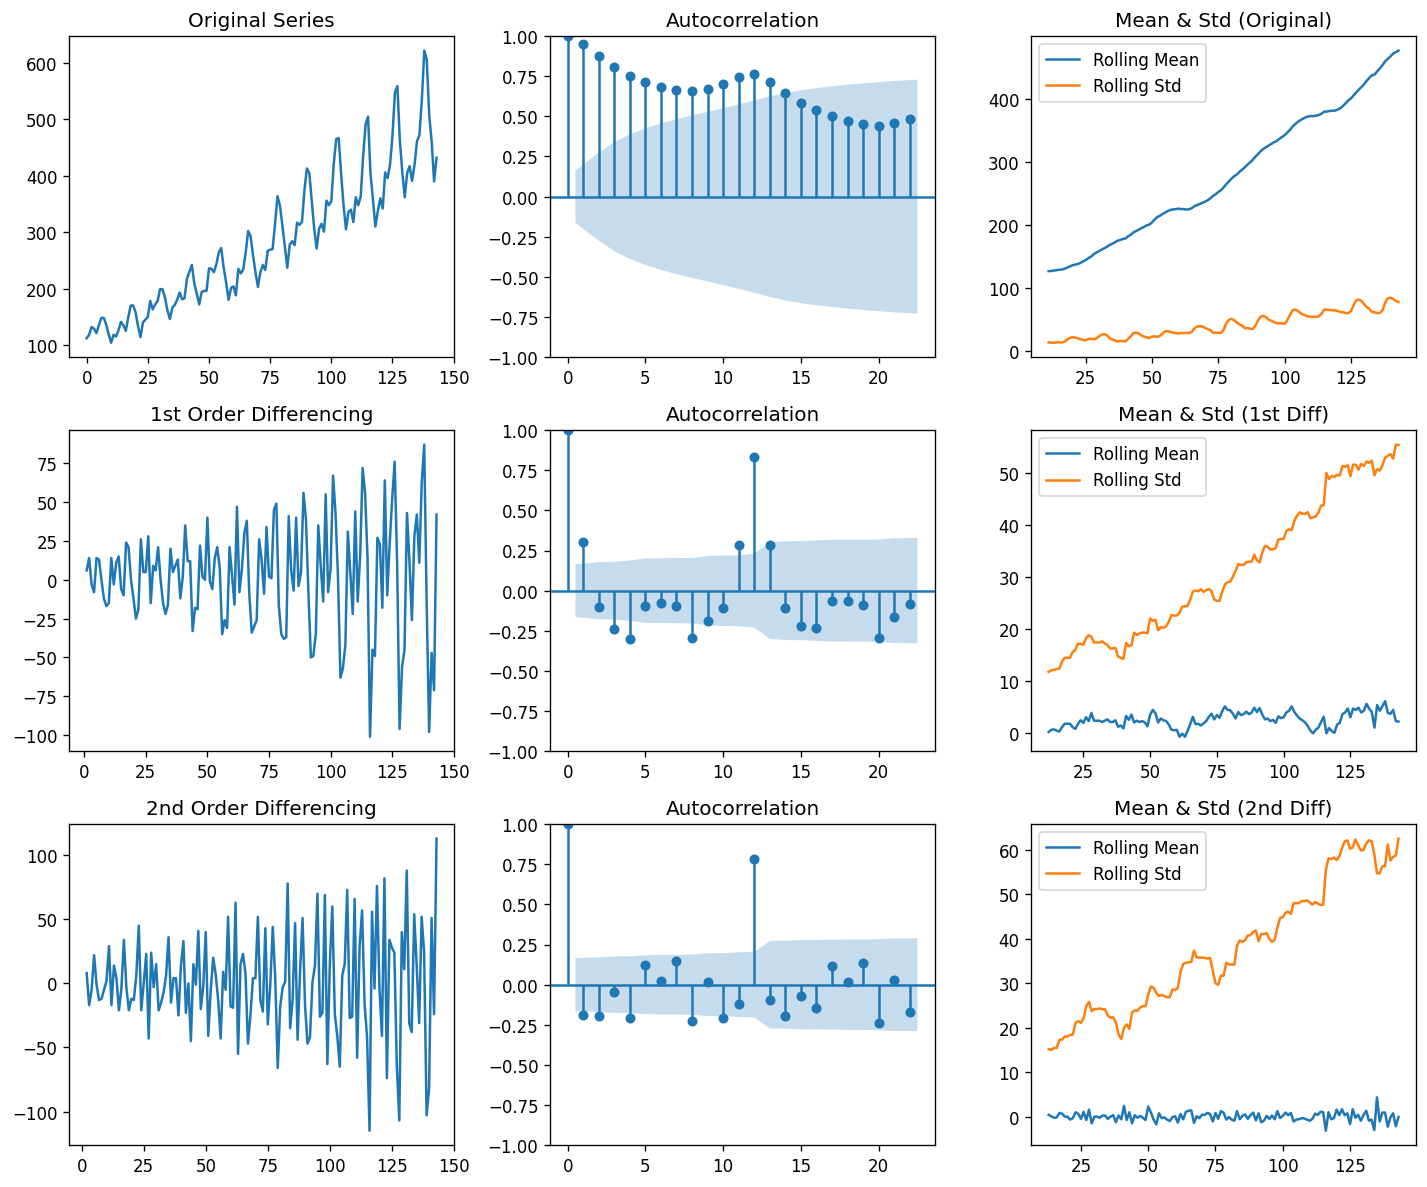

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'figure.figsize':(12,10), 'figure.dpi':120})

# Prepare series
orig = df.Passengers
diff1 = df.Passengers.diff().dropna()
diff2 = df.Passengers.diff().diff().dropna()

fig, axes = plt.subplots(3, 3, sharex=False, sharey=False)

# Original series
axes[0, 0].plot(orig); axes[0, 0].set_title('Original Series')
plot_acf(orig, ax=axes[0, 1])
pd.Series(orig).rolling(window=12).mean().plot(ax=axes[0, 2], label='Rolling Mean')
pd.Series(orig).rolling(window=12).std().plot(ax=axes[0, 2], label='Rolling Std')
axes[0, 2].legend(loc='best'); axes[0, 2].set_title('Mean & Std (Original)')

# 1st differencing
axes[1, 0].plot(diff1); axes[1, 0].set_title('1st Order Differencing')
plot_acf(diff1, ax=axes[1, 1])
diff1.rolling(window=12).mean().plot(ax=axes[1, 2], label='Rolling Mean')
diff1.rolling(window=12).std().plot(ax=axes[1, 2], label='Rolling Std')
axes[1, 2].legend(loc='best'); axes[1, 2].set_title('Mean & Std (1st Diff)')

# 2nd differencing
axes[2, 0].plot(diff2); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(diff2, ax=axes[2, 1])
diff2.rolling(window=12).mean().plot(ax=axes[2, 2], label='Rolling Mean')
diff2.rolling(window=12).std().plot(ax=axes[2, 2], label='Rolling Std')
axes[2, 2].legend(loc='best'); axes[2, 2].set_title('Mean & Std (2nd Diff)')

plt.tight_layout()
plt.show()


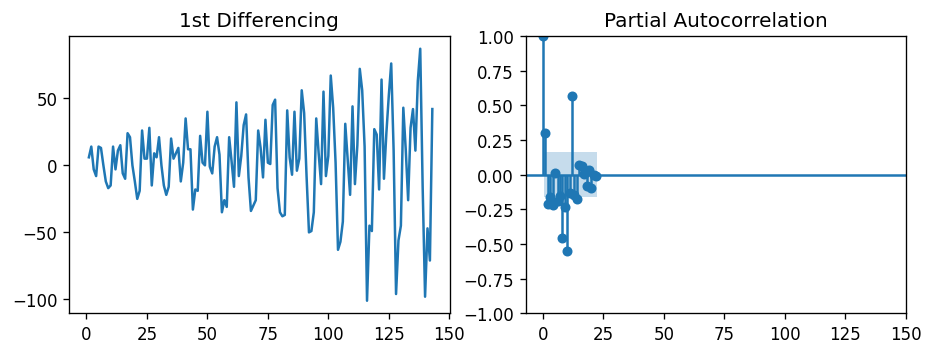

In [21]:
# PACF plot of 1st differenced series
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(df.Passengers.diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,5))
plot_pacf(df.Passengers.diff().dropna(), ax=axes[1])

plt.show()

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Tue, 16 Sep 2025   AIC                           1394.683
Time:                        15:55:22   BIC                           1403.571
Sample:                             0   HQIC                          1398.294
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

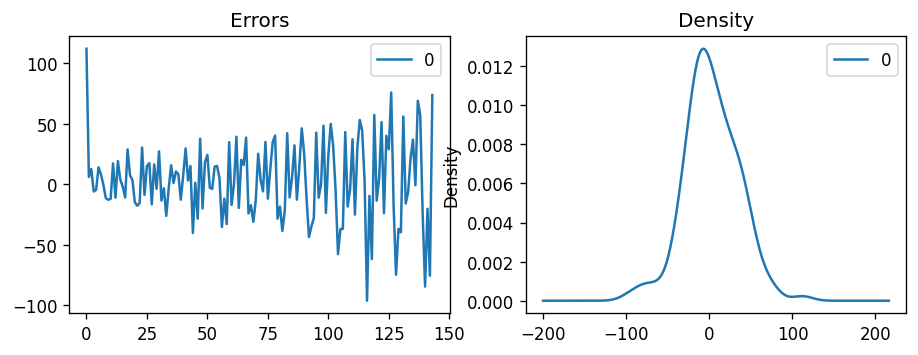

In [22]:
from statsmodels.tsa.arima.model import ARIMA


# 1,1,1 ARIMA Model
model = ARIMA(df.Passengers, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

# Plot residual errors
errors = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
errors.plot(title="Errors", ax=ax[0])
errors.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

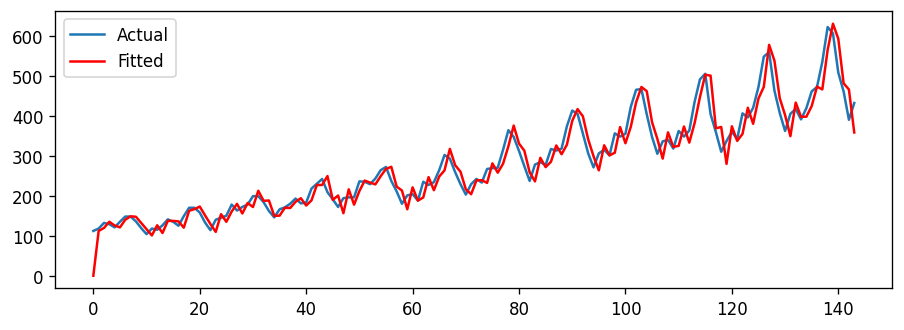

In [23]:
# Actual vs Fitted
plt.plot(df.Passengers, label="Actual")
plt.plot(model_fit.predict(start=0, end=len(df.Passengers)-1), label="Fitted", color="red")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Tue, 16 Sep 2025   AIC                           1353.347
Time:                        15:55:26   BIC                           1368.161
Sample:                             0   HQIC                          1359.366
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.814      0.0

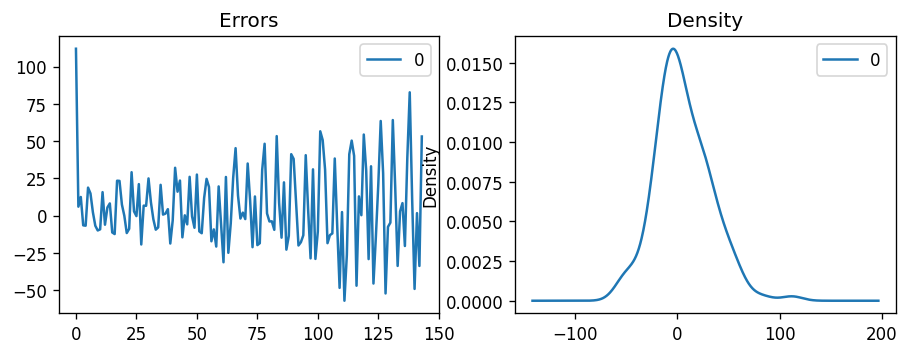

In [24]:
# 2,1,2 ARIMA Model
model = ARIMA(df.Passengers, order=(2,1,2))
model_fit = model.fit()
print(model_fit.summary())

# Plot residual errors
errors = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
errors.plot(title="Errors", ax=ax[0])
errors.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

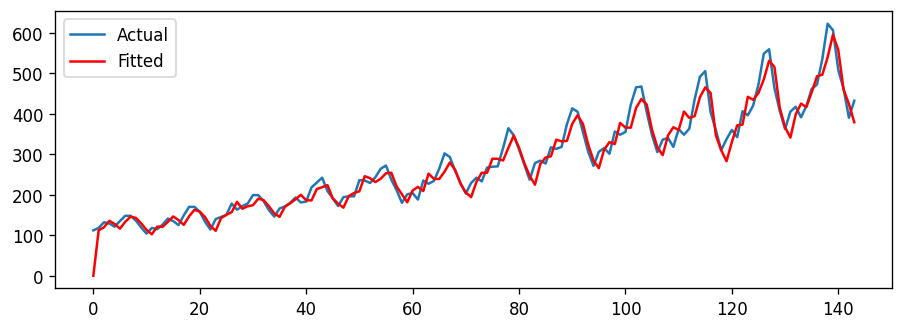

In [25]:
# Actual vs Fitted
plt.plot(df.Passengers, label="Actual")
plt.plot(model_fit.predict(start=0, end=len(df.Passengers)-1), label="Fitted", color="red")
plt.legend()
plt.show()

In [26]:
from statsmodels.tsa.stattools import acf

# Create Training and Test
train = df.Passengers[:85]
test = df.Passengers[85:]

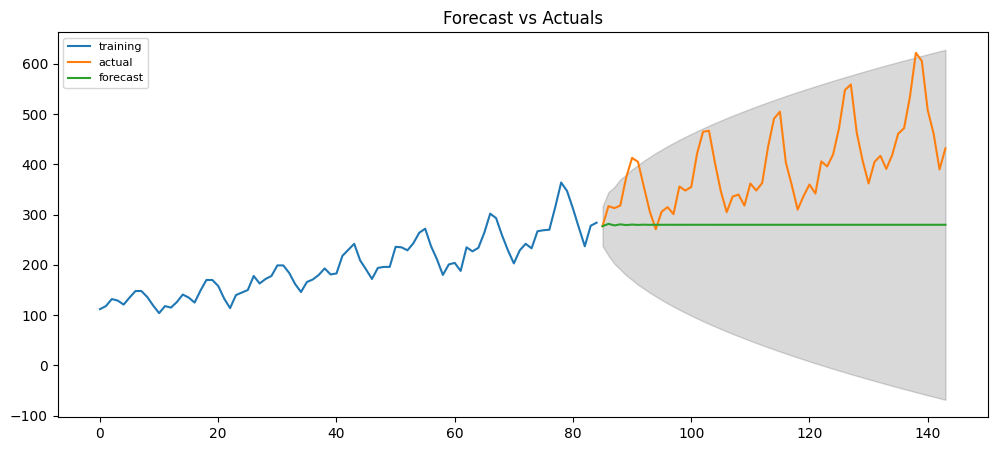

In [27]:
# Build Model
model = ARIMA(train, order=(1, 1, 1))
fitted = model.fit()

# Forecast
fc = fitted.get_forecast(steps = len(test))
fc_series = pd.Series(fc.predicted_mean, index=test.index)

# Confidence intervals
conf = fc.conf_int(alpha=0.05)
lower_series = conf[conf.columns[0]]
upper_series = conf[conf.columns[1]]

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [28]:
# Accuracy metrics
def forecast_accuracy(forecast, actual):

    mse = np.mean((forecast - actual) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(forecast - actual))
    mape = np.mean(np.abs((forecast - actual) / actual)) * 100

    return {"mse": mse, "rmse": rmse, "mae": mae, "mape": mape}

print(forecast_accuracy(fc.predicted_mean.values, test.values))

{'mse': np.float64(20337.143502781248), 'rmse': np.float64(142.6083570579973), 'mae': np.float64(118.81785572353994), 'mape': np.float64(27.241375320030915)}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


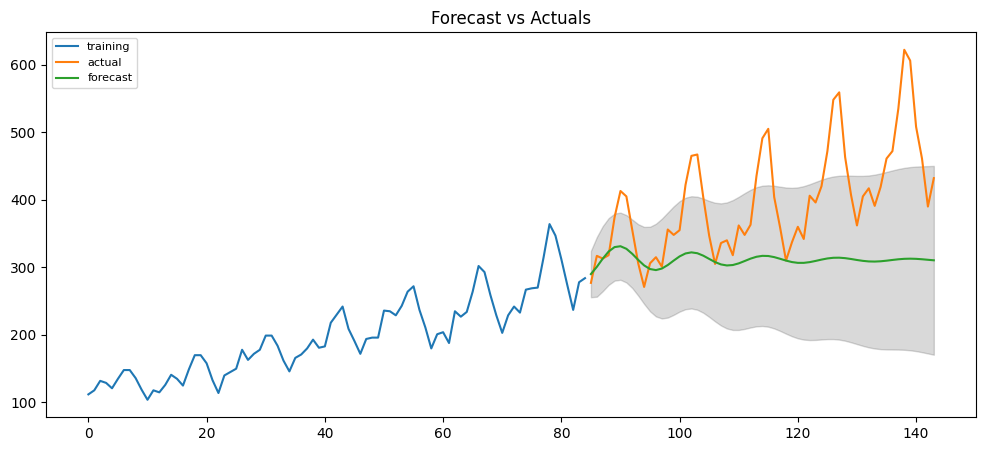

In [29]:
# Build Model
model = ARIMA(train, order=(2, 1, 2))
fitted = model.fit()

# Forecast
fc = fitted.get_forecast(steps = len(test))
fc_series = pd.Series(fc.predicted_mean, index=test.index)

# Confidence intervals
conf = fc.conf_int(alpha=0.05)
lower_series = conf[conf.columns[0]]
upper_series = conf[conf.columns[1]]

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [30]:
# Accuracy metrics
def forecast_accuracy(forecast, actual):

    mse = np.mean((forecast - actual) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(forecast - actual))
    mape = np.mean(np.abs((forecast - actual) / actual)) * 100

    return {"mse": mse, "rmse": rmse, "mae": mae, "mape": mape}

print(forecast_accuracy(fc.predicted_mean.values, test.values))

{'mse': np.float64(13439.189812061299), 'rmse': np.float64(115.92751964939687), 'mae': np.float64(89.01646986401887), 'mape': np.float64(19.812437976892184)}
